# Group 6 RF Intrusion Detection Project (AAI-540)
## 1. Project Overview: Machine Learning-Based RF Intrusion Detection System

This project develops a supervised multi-class machine learning system for classifying radiofrequency (RF) activity using spectrogram images.

The objective is to identify different RF activity categories and provide a repeatable machine learning workflow that supports data preparation, model training, evaluation, deployment, and monitoring.


## 2. Environment Setup and Imports

This section imports the libraries required for data inspection, visualization, preprocessing, and machine learning. Random seeds are also defined to support reproducibility across notebook runs.


In [ ]:
# ============================================
# Environment Setup
# ============================================

%pip install -q kagglehub sagemaker boto3 scikit-learn pandas

import shutil
from pathlib import Path
import os
import time
import random
from collections import Counter

import boto3
import sagemaker
from sagemaker.core.helper.session_helper import Session

import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Environment setup complete.")


## 3. Raw Dataset Collection from Kaggle

The original Kaggle RF intrusion dataset is already split into train, validation, and test folders. 
For this assignment, we first treat all of those folders as raw data, combine their metadata into one dataset, 
and then create a new split that matches the assignment requirements:

- 40% training data
- 10% validation data
- 10% test data
- 40% production holdout data

The resulting files are uploaded to an S3 data lake so they can be cataloged, queried, and used in later stages of the ML pipeline.

### 3.1 Download Dataset from Kaggle

In [ ]:
print("\nDownloading Kaggle dataset...")

kaggle_download_path = kagglehub.dataset_download(
    "hector484/unified-multi-class-rf-intrusion-dataset"
)

kaggle_root = Path(kaggle_download_path)

print("Kaggle dataset downloaded to:")
print(kaggle_root)

print("\nTop-level downloaded contents:")
for item in kaggle_root.iterdir():
    print(" -", item.name)

100%|██████████| 324M/324M [00:13<00:00, 25.8MB/s] 

Extracting files...


Kaggle dataset downloaded to:
/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1

Top-level downloaded contents:
 - unified_dataset


### 3.2 Verify Original Dataset Structure

In [5]:
from pathlib import Path

# Point to the actual dataset folder inside the Kaggle download
dataset_root = Path(kaggle_download_path) / "unified_dataset"

print("Dataset root:")
print(dataset_root)

print("\nDataset root exists:", dataset_root.exists())

print("\nTop-level contents:")
for item in dataset_root.iterdir():
    print(" -", item.name)

original_splits = ["train", "val", "test"]

print("\nChecking expected split folders:")
for split in original_splits:
    split_path = dataset_root / split
    print(f"{split}: {split_path.exists()}")

Dataset root:
/home/sagemaker-user/.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset

Dataset root exists: True

Top-level contents:
 - dataset_verification.png
 - test
 - train
 - val

Checking expected split folders:
train: True
val: True
test: True


### 3.3 Inspect Original Classes and Splits

In [6]:
# Build one combined metadata dataframe

records = []

for original_split in original_splits:
    split_path = dataset_root / original_split
    
    for class_dir in split_path.iterdir():
        if class_dir.is_dir():
            class_label = class_dir.name
            
            for image_path in class_dir.glob("*.png"):
                records.append({
                    "image_path": str(image_path),
                    "filename": image_path.name,
                    "class_label": class_label,
                    "original_split": original_split
                })

df_all = pd.DataFrame(records)

if df_all.empty:
    raise ValueError("No PNG images were found. Check the dataset folder structure.")

print("\nTotal images found:", len(df_all))

print("\nClass counts from combined original dataset:")
display(df_all["class_label"].value_counts())

print("\nOriginal Kaggle split counts:")
display(df_all["original_split"].value_counts())


Total images found: 24000

Class counts from combined original dataset:


class_label
Benign            4000
Broadband_Jam     4000
Human             4000
Machine           4000
Narrowband_Jam    4000
Wildlife          4000
Name: count, dtype: int64


Original Kaggle split counts:


original_split
train    16800
val       3600
test      3600
Name: count, dtype: int64

## 4. S3 Data Lake Setup

### 4.1 Define S3 Bucket and Project Prefix

In [3]:
# AWS / S3 setup without using sagemaker.Session()

boto_session = boto3.Session()
region = boto_session.region_name

sts_client = boto_session.client("sts")
account_id = sts_client.get_caller_identity()["Account"]

bucket = f"sagemaker-{region}-{account_id}"

print("AWS region:", region)
print("AWS account ID:", account_id)
print("SageMaker default-style bucket:", bucket)

s3_client = boto3.client("s3")

try:
    s3_client.head_bucket(Bucket=bucket)
    print("Bucket already exists:", bucket)
except Exception:
    print("Creating bucket:", bucket)
    
    if region == "us-east-1":
        s3_client.create_bucket(Bucket=bucket)
    else:
        s3_client.create_bucket(
            Bucket=bucket,
            CreateBucketConfiguration={"LocationConstraint": region}
        )

    print("Bucket created:", bucket)

AWS region: us-east-1
AWS account ID: 545286875883
SageMaker default-style bucket: sagemaker-us-east-1-545286875883
Bucket already exists: sagemaker-us-east-1-545286875883


### 4.2 Create Required 40/10/10/40 Split

In [8]:
# Create 40/10/10/40 split

# First reserve 40% as production holdout
df_modeling, df_production = train_test_split(
    df_all,
    test_size=0.40,
    random_state=SEED,
    stratify=df_all["class_label"]
)

# Remaining 60% should become:
# train = 40% of total = 2/3 of remaining 60%
# validation + test = 20% of total = 1/3 of remaining 60%
df_train, df_temp = train_test_split(
    df_modeling,
    test_size=1/3,
    random_state=SEED,
    stratify=df_modeling["class_label"]
)

# Split remaining temp evenly into validation and test
df_validation, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=df_temp["class_label"]
)

df_train = df_train.copy()
df_validation = df_validation.copy()
df_test = df_test.copy()
df_production = df_production.copy()

df_train["assignment_split"] = "train"
df_validation["assignment_split"] = "validation"
df_test["assignment_split"] = "test"
df_production["assignment_split"] = "production"

df_split = pd.concat(
    [df_train, df_validation, df_test, df_production],
    ignore_index=True
)

print("\nFinal assignment split percentages:")
display(df_split["assignment_split"].value_counts(normalize=True).mul(100).round(2))

print("\nFinal assignment split counts:")
display(df_split["assignment_split"].value_counts())

print("\nClass counts by assignment split:")
display(pd.crosstab(df_split["assignment_split"], df_split["class_label"]))


Final assignment split percentages:


assignment_split
train         40.0
production    40.0
validation    10.0
test          10.0
Name: proportion, dtype: float64


Final assignment split counts:


assignment_split
train         9600
production    9600
validation    2400
test          2400
Name: count, dtype: int64


Class counts by assignment split:


class_label,Benign,Broadband_Jam,Human,Machine,Narrowband_Jam,Wildlife
assignment_split,,,,,,
production,1600,1600,1600,1600,1600,1600
test,400,400,400,400,400,400
train,1600,1600,1600,1600,1600,1600
validation,400,400,400,400,400,400


### 4.3 Create Local Curated Split Folder

In [9]:
# Create local curated split folder

resplit_root = Path("data/rf_assignment_split")

if resplit_root.exists():
    shutil.rmtree(resplit_root)

for _, row in df_split.iterrows():
    source_path = Path(row["image_path"])
    
    target_path = (
        resplit_root
        / row["assignment_split"]
        / row["class_label"]
        / row["filename"]
    )
    
    target_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source_path, target_path)

print("\nCreated local curated split folder:")
print(resplit_root.resolve())

print("\nCurated local split image counts:")
for split_name in ["train", "validation", "test", "production"]:
    image_count = len(list((resplit_root / split_name).glob("*/*.png")))
    print(f"{split_name}: {image_count}")


Created local curated split folder:
/home/sagemaker-user/aai-540-final-project-group6/data/rf_assignment_split

Curated local split image counts:
train: 9600
validation: 2400
test: 2400
production: 9600


## 4.4 Upload Raw, Curated, and Metadata Files to S3

This cell saves the final assignment split metadata as a CSV file and uploads the project data into Amazon S3. The metadata file contains important information for each RF spectrogram image, including the image path, filename, class label, original Kaggle split, and the new assignment split. This metadata file will be useful later for cataloging and querying the dataset with Athena.

The cell defines an S3 project prefix called `rf-intrusion-datalake`, which organizes the project files into separate data lake zones. The original Kaggle dataset is uploaded to the `raw/kaggle_original/` location, preserving the source dataset structure. The newly created assignment split is uploaded to the `curated/assignment_split/` location, which contains the required 40% training, 10% validation, 10% test, and 40% production holdout split. Finally, the metadata CSV is uploaded to the `metadata/` location.

Together, these uploads create the S3 data lake structure for the project. The raw folder stores the original collected data, the curated folder stores the processed assignment-ready dataset, and the metadata folder stores a structured CSV file that can be used for Athena table creation and later ML pipeline steps.

In [ ]:
# Save metadata CSV locally

metadata_path = Path("rf_intrusion_assignment_split_metadata.csv")
df_split.to_csv(metadata_path, index=False)

print("\nSaved metadata CSV locally:")
print(metadata_path.resolve())


# Upload raw dataset, curated split, and metadata to S3

project_prefix = "rf-intrusion-datalake"

s3_raw_prefix = f"s3://{bucket}/{project_prefix}/raw/kaggle_original/"
s3_curated_prefix = f"s3://{bucket}/{project_prefix}/curated/assignment_split/"
s3_metadata_prefix = f"s3://{bucket}/{project_prefix}/metadata/"

print("\nUploading raw Kaggle dataset to S3...")
!aws s3 sync "{dataset_root}" "{s3_raw_prefix}"

print("\nUploading curated assignment split to S3...")
!aws s3 sync "{resplit_root}" "{s3_curated_prefix}"

print("\nUploading metadata CSV to S3...")
s3_client = boto3.client("s3")

metadata_s3_key = f"{project_prefix}/metadata/rf_intrusion_assignment_split_metadata.csv"

s3_client.upload_file(
    Filename=str(metadata_path),
    Bucket=bucket,
    Key=metadata_s3_key
)

metadata_s3_uri = f"s3://{bucket}/{metadata_s3_key}"


Saved metadata CSV locally:
/home/sagemaker-user/aai-540-final-project-group6/rf_intrusion_assignment_split_metadata.csv

Uploading raw Kaggle dataset to S3...
upload: ../.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/dataset_verification.png to s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/raw/kaggle_original/dataset_verification.png
upload: ../.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/test/Benign/dronerf_047046.png to s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/raw/kaggle_original/test/Benign/dronerf_047046.png
upload: ../.cache/kagglehub/datasets/hector484/unified-multi-class-rf-intrusion-dataset/versions/1/unified_dataset/test/Benign/dronerf_046648.png to s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/raw/kaggle_original/test/Benign/dronerf_046648.png
upload: ../.cache/kagglehub/datasets/hector484/unified-multi-class-rf-i

### 4.5 Verify S3 Data Lake Setup

In [13]:
# Final summary

print("S3 DATA LAKE SETUP SUMMARY:")
print("Raw Kaggle data uploaded to:")
print(s3_raw_prefix)
print()
print("Curated assignment split uploaded to:")
print(s3_curated_prefix)
print()
print("Metadata CSV uploaded to:")
print(metadata_s3_uri)
print()
print("Final split percentages:")
display(df_split["assignment_split"].value_counts(normalize=True).mul(100).round(2))
print()
print("Final split counts:")
display(df_split["assignment_split"].value_counts())

S3 DATA LAKE SETUP SUMMARY:
Raw Kaggle data uploaded to:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/raw/kaggle_original/

Curated assignment split uploaded to:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/

Metadata CSV uploaded to:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/metadata/rf_intrusion_assignment_split_metadata.csv

Final split percentages:


assignment_split
train         40.0
production    40.0
validation    10.0
test          10.0
Name: proportion, dtype: float64


Final split counts:


assignment_split
train         9600
production    9600
validation    2400
test          2400
Name: count, dtype: int64

### 4.6 S3 Data Lake Setup Summary

The RF Intrusion Detection dataset was successfully collected from Kaggle and uploaded into an Amazon S3 data lake. The original Kaggle dataset was stored in the `raw/kaggle_original/` S3 location to preserve the source data structure.

The original train, validation, and test folders were then combined and re-split to match the assignment requirements. The curated assignment split was uploaded to the `curated/assignment_split/` S3 location and contains 9,600 training images, 2,400 validation images, 2,400 test images, and 9,600 production holdout images. This corresponds to a 40% training, 10% validation, 10% testing, and 40% production split.

A metadata CSV was also uploaded to the `metadata/` folder in S3. This file records each image’s filename, class label, original Kaggle split, and new assignment split. The metadata file will be used in the next stage to create an Athena table for cataloging and querying the dataset.

## 5. Athena Cataloging and Querying

To enable cataloging and querying of the RF Intrusion Detection dataset, we create an Athena table over a structured metadata CSV stored in the S3 data lake. The actual RF spectrogram files are PNG images, which are not ideal for direct SQL querying. Instead, the metadata file catalogs each image by filename, class label, original Kaggle split, assignment split, and S3 image location.

This allows Athena to query the dataset at the catalog level. For example, we can count images by class, verify the 40/10/10/40 assignment split, identify how many Machine-class images are available, and retrieve S3 paths for specific subsets of the data.

### 5.1 Create Athena-Ready Metadata File

In [24]:
# Project/S3 setup
bucket = "sagemaker-us-east-1-545286875883"
project_prefix = "rf-intrusion-datalake"

s3_curated_prefix = f"s3://{bucket}/{project_prefix}/curated/assignment_split/"
athena_metadata_prefix = f"{project_prefix}/metadata/athena/"
athena_metadata_s3_location = f"s3://{bucket}/{athena_metadata_prefix}"

# Create a clean Athena metadata dataframe from df_split
# df_split should already exist from the data lake setup step
athena_df = df_split.copy()

# Rename image_path to local_image_path because it points to the local/Kaggle cache
athena_df = athena_df.rename(columns={"image_path": "local_image_path"})

# Add record_id
athena_df.insert(0, "record_id", range(1, len(athena_df) + 1))

# Add S3 URI for each image in the curated assignment split
athena_df["s3_image_uri"] = athena_df.apply(
    lambda row: (
        f"{s3_curated_prefix}"
        f"{row['assignment_split']}/"
        f"{row['class_label']}/"
        f"{row['filename']}"
    ),
    axis=1
)

# Reorder columns for Athena table
athena_df = athena_df[
    [
        "record_id",
        "filename",
        "class_label",
        "original_split",
        "assignment_split",
        "local_image_path",
        "s3_image_uri"
    ]
]

# Save locally
athena_metadata_path = Path("rf_intrusion_athena_metadata.csv")
athena_df.to_csv(athena_metadata_path, index=False)

print("Athena metadata saved locally:")
print(athena_metadata_path.resolve())

display(athena_df.head())

# Upload to S3
s3_client = boto3.client("s3")

athena_metadata_key = f"{athena_metadata_prefix}rf_intrusion_athena_metadata.csv"

s3_client.upload_file(
    Filename=str(athena_metadata_path),
    Bucket=bucket,
    Key=athena_metadata_key
)

athena_metadata_s3_uri = f"s3://{bucket}/{athena_metadata_key}"

print("\nAthena metadata uploaded to:")
print(athena_metadata_s3_uri)

print("\nAthena metadata folder location:")
print(athena_metadata_s3_location)

Athena metadata saved locally:
/home/sagemaker-user/aai-540-final-project-group6/rf_intrusion_athena_metadata.csv


,record_id,filename,class_label,original_split,assignment_split,local_image_path,s3_image_uri
0,1,radar_003904.png,Human,train,train,/home/sagemaker-user/.cache/kagglehub/datasets...,s3://sagemaker-us-east-1-545286875883/rf-intru...
1,2,dronerf_066126.png,Benign,train,train,/home/sagemaker-user/.cache/kagglehub/datasets...,s3://sagemaker-us-east-1-545286875883/rf-intru...
2,3,jam_Benign_005449.png,Benign,train,train,/home/sagemaker-user/.cache/kagglehub/datasets...,s3://sagemaker-us-east-1-545286875883/rf-intru...
3,4,aug_Narrowband_Jam_000695.png,Narrowband_Jam,train,train,/home/sagemaker-user/.cache/kagglehub/datasets...,s3://sagemaker-us-east-1-545286875883/rf-intru...
4,5,aug_Narrowband_Jam_000377.png,Narrowband_Jam,train,train,/home/sagemaker-user/.cache/kagglehub/datasets...,s3://sagemaker-us-east-1-545286875883/rf-intru...



Athena metadata uploaded to:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/metadata/athena/rf_intrusion_athena_metadata.csv

Athena metadata folder location:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/metadata/athena/


### 5.2 Create Athena Database and External Table

In [26]:
region = boto3.Session().region_name

athena_client = boto3.client("athena", region_name=region)

athena_database = "rf_intrusion_db"
athena_table = "rf_image_metadata"

athena_results_prefix = f"s3://{bucket}/{project_prefix}/athena-results/"

print("Athena database:", athena_database)
print("Athena table:", athena_table)
print("Athena query results location:", athena_results_prefix)


def run_athena_query(query, database=None):
    """Run an Athena query and wait for it to finish."""
    
    query_config = {
        "QueryString": query,
        "ResultConfiguration": {
            "OutputLocation": athena_results_prefix
        }
    }
    
    if database is not None:
        query_config["QueryExecutionContext"] = {
            "Database": database
        }
    
    response = athena_client.start_query_execution(**query_config)
    query_execution_id = response["QueryExecutionId"]
    
    while True:
        result = athena_client.get_query_execution(
            QueryExecutionId=query_execution_id
        )
        
        status = result["QueryExecution"]["Status"]["State"]
        
        if status in ["SUCCEEDED", "FAILED", "CANCELLED"]:
            break
        
        time.sleep(2)
    
    if status != "SUCCEEDED":
        reason = result["QueryExecution"]["Status"].get(
            "StateChangeReason",
            "No failure reason provided."
        )
        raise RuntimeError(f"Athena query failed with status {status}: {reason}")
    
    return query_execution_id


# Create database
create_database_query = f"""
CREATE DATABASE IF NOT EXISTS {athena_database}
"""

run_athena_query(create_database_query)

print("Athena database created or already exists.")


# Drop table if rerunning notebook
drop_table_query = f"""
DROP TABLE IF EXISTS {athena_table}
"""

run_athena_query(drop_table_query, database=athena_database)

print("Old Athena table dropped if it existed.")


# Create external table over metadata CSV folder
create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {athena_table} (
    record_id INT,
    filename STRING,
    class_label STRING,
    original_split STRING,
    assignment_split STRING,
    local_image_path STRING,
    s3_image_uri STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    'separatorChar' = ',',
    'quoteChar' = '"',
    'escapeChar' = '\\\\'
)
STORED AS TEXTFILE
LOCATION '{athena_metadata_s3_location}'
TBLPROPERTIES (
    'skip.header.line.count' = '1'
)
"""

run_athena_query(create_table_query, database=athena_database)

print("Athena external table created successfully.")

Athena database: rf_intrusion_db
Athena table: rf_image_metadata
Athena query results location: s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/athena-results/
Athena database created or already exists.
Old Athena table dropped if it existed.
Athena external table created successfully.


### 5.3 Define Athena Query Helper Function

This cell defines a helper function named `athena_query_to_dataframe()`. The function runs a SQL query in Athena, waits for the query to finish using the previously defined `run_athena_query()` function, retrieves the results from Athena, and converts the output into a Pandas dataframe.

This makes the later Athena queries easier to read and display in the notebook. Instead of manually calling the Athena client each time, we can write a SQL query, pass it into this function, and display the results as a dataframe.

In [29]:
# ============================================
# Test Athena table with SQL queries
# ============================================

import pandas as pd

def athena_query_to_dataframe(query, database=athena_database):
    """Run Athena query and return results as a Pandas dataframe."""
    
    query_execution_id = run_athena_query(query, database=database)
    
    results = athena_client.get_query_results(
        QueryExecutionId=query_execution_id
    )
    
    rows = results["ResultSet"]["Rows"]
    
    if len(rows) == 0:
        return pd.DataFrame()
    
    columns = [
        col.get("VarCharValue", "")
        for col in rows[0]["Data"]
    ]
    
    data = []
    for row in rows[1:]:
        values = [
            col.get("VarCharValue", None)
            for col in row["Data"]
        ]
        data.append(values)
    
    return pd.DataFrame(data, columns=columns)


### 5.4 Run Athena SQL Queries

This cell runs several SQL queries against the Athena metadata table to verify that the RF intrusion dataset was cataloged correctly. The first query checks the total number of image records in the table. The second query counts images by assignment split to confirm the required 40/10/10/40 split. The third query counts images by class and split to verify that all six RF activity classes are evenly represented across the dataset. The final query retrieves sample records from the `Machine` class, including the S3 image paths that point back to the curated data lake.

In [30]:
# Query 1: total records
query_total = f"""
SELECT COUNT(*) AS total_images
FROM {athena_table}
"""

df_total = athena_query_to_dataframe(query_total)
display(df_total)


# Query 2: images by assignment split
query_split_counts = f"""
SELECT assignment_split, COUNT(*) AS image_count
FROM {athena_table}
GROUP BY assignment_split
ORDER BY image_count DESC
"""

df_split_counts = athena_query_to_dataframe(query_split_counts)
display(df_split_counts)


# Query 3: images by class and split
query_class_split = f"""
SELECT assignment_split, class_label, COUNT(*) AS image_count
FROM {athena_table}
GROUP BY assignment_split, class_label
ORDER BY assignment_split, class_label
"""

df_class_split = athena_query_to_dataframe(query_class_split)
display(df_class_split)


# Query 4: Machine class records
query_machine = f"""
SELECT filename, class_label, assignment_split, s3_image_uri
FROM {athena_table}
WHERE class_label = 'Machine'
LIMIT 10
"""

df_machine = athena_query_to_dataframe(query_machine)
display(df_machine)

,total_images
0,24000


,assignment_split,image_count
0,train,9600
1,production,9600
2,validation,2400
3,test,2400


,assignment_split,class_label,image_count
0,production,Benign,1600
1,production,Broadband_Jam,1600
2,production,Human,1600
3,production,Machine,1600
4,production,Narrowband_Jam,1600
5,production,Wildlife,1600
6,test,Benign,400
7,test,Broadband_Jam,400
8,test,Human,400
9,test,Machine,400


,filename,class_label,assignment_split,s3_image_uri
0,dronerf_013659.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
1,radar_002177.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
2,dronerf_115658.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
3,dronerf_035345.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
4,dronerf_110507.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
5,radar_001579.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
6,dronerf_028642.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
7,dronerf_120806.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
8,dronerf_001370.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...
9,dronerf_030913.png,Machine,train,s3://sagemaker-us-east-1-545286875883/rf-intru...


### 5.5 Athena Setup Summary

An Athena database and external table were created to catalog the RF Intrusion Detection dataset. Since the original dataset consists of PNG spectrogram images, Athena was configured to query a metadata CSV rather than the raw image pixels. This metadata table includes each image’s filename, class label, original Kaggle split, assignment split, local path, and S3 image URI.

The Athena queries confirm that the dataset contains 24,000 total images and that the assignment-required split was successfully preserved in the S3 data lake. The table can now be used to query subsets of the dataset, such as all Machine-class spectrograms or the number of images available in each training, validation, test, and production split.

## 6. Load Curated Dataset from S3 Data Lake

The Unified Multi-Class RF Intrusion Dataset is stored in the project S3 data lake under the curated assignment split location. The curated split was created from the original Kaggle train, validation, and test folders and reorganized into the assignment-required structure:

- Training data: 40%
- Validation data: 10%
- Test data: 10%
- Production holdout data: 40%

For model development, the curated S3 data is synced into the SageMaker Studio environment as a local working copy. TensorFlow reads from the local synced folders, while S3 remains the source of truth for the data lake.


In [ ]:
# S3 source of truth: curated assignment split in the data lake
try:
    s3_dataset_dir = s3_curated_prefix
except NameError:
    s3_dataset_dir = "s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/"

# Local working copy for TensorFlow
# TensorFlow image_dataset_from_directory expects local folders
local_dataset_dir = Path("data/from_s3_datalake/rf_assignment_split")

print("S3 dataset directory:")
print(s3_dataset_dir)

print("\nLocal dataset cache:")
print(local_dataset_dir.resolve())

# Sync S3 data lake contents into local SageMaker Studio storage
!aws s3 sync "{s3_dataset_dir}" "{local_dataset_dir}"

# Define local split directories
train_dir = local_dataset_dir / "train"
val_dir = local_dataset_dir / "validation"
test_dir = local_dataset_dir / "test"
production_dir = local_dataset_dir / "production"

print("\nTraining directory:", train_dir)
print("Validation directory:", val_dir)
print("Testing directory:", test_dir)
print("Production directory:", production_dir)

print("\nLocal dataset contents:")
for item in local_dataset_dir.iterdir():
    print(" -", item.name)


S3 dataset directory:
s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/

Local dataset cache:
/home/sagemaker-user/aai-540-final-project-group6/data/from_s3_datalake/rf_assignment_split
download: s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/production/Benign/dronerf_046590.png to data/from_s3_datalake/rf_assignment_split/production/Benign/dronerf_046590.png
download: s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/production/Benign/dronerf_046535.png to data/from_s3_datalake/rf_assignment_split/production/Benign/dronerf_046535.png
download: s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/production/Benign/dronerf_046569.png to data/from_s3_datalake/rf_assignment_split/production/Benign/dronerf_046569.png
download: s3://sagemaker-us-east-1-545286875883/rf-intrusion-datalake/curated/assignment_split/production/Benign/dronerf_046808.png to d

## 7. Exploratory Data Analysis

This section verifies the dataset directory structure and confirms that the expected training, validation, and test partitions are available before further processing.


### 7.1 Dataset Structure

In [15]:
print("Top-level dataset contents:\n")

for item in sorted(os.listdir(local_dataset_dir)):
    item_path = os.path.join(local_dataset_dir, item)

    if os.path.isdir(item_path):
        print(f"[DIR]  {item}")
    else:
        print(f"[FILE] {item}")


Top-level dataset contents:

[DIR]  production
[DIR]  test
[DIR]  train
[DIR]  validation


#### 7.1.1 Define Dataset Splits

In [16]:
train_dir = os.path.join(local_dataset_dir, "train")
val_dir = os.path.join(local_dataset_dir, "validation")
test_dir = os.path.join(local_dataset_dir, "test")
production_dir = local_dataset_dir / "production"

print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Testing directory:", test_dir)
print("Production directory:", production_dir)


Training directory: data/from_s3_datalake/rf_assignment_split/train
Validation directory: data/from_s3_datalake/rf_assignment_split/validation
Testing directory: data/from_s3_datalake/rf_assignment_split/test
Production directory: data/from_s3_datalake/rf_assignment_split/production


### 7.2 RF Activity Classes

The dataset contains six RF activity classes:

- Benign
- Broadband Jam
- Human
- Machine
- Narrowband Jam
- Wildlife

These folder names serve as the class labels for the supervised multi-class classification problem.


In [17]:
class_names = sorted([
    folder
    for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print(f"Number of classes: {len(class_names)}\n")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")


Number of classes: 6

0: Benign
1: Broadband_Jam
2: Human
3: Machine
4: Narrowband_Jam
5: Wildlife


### 7.3 Dataset Distribution

The number of images in each class and dataset split is examined to identify potential class imbalance and confirm the total data volume available for training, validation, and testing.


In [18]:
# Count Images by Split and Class

def count_images(directory):
    counts = {}

    for class_name in class_names:
        class_dir = Path(directory) / class_name

        counts[class_name] = len([
            file
            for file in os.listdir(class_dir)
            if file.lower().endswith(".png")
        ])

    return counts


train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)
production_counts = count_images(production_dir)

print("Class Distribution\n")

print(
    f"{'Class':<20} "
    f"{'Train':>8} "
    f"{'Val':>8} "
    f"{'Test':>8} "
    f"{'Prod':>8} "
    f"{'Total':>8}"
)
print("-" * 76)

for class_name in class_names:
    train_count = train_counts[class_name]
    val_count = val_counts[class_name]
    test_count = test_counts[class_name]
    production_count = production_counts[class_name]
    total = train_count + val_count + test_count + production_count

    print(
        f"{class_name:<20}"
        f"{train_count:>8}"
        f"{val_count:>8}"
        f"{test_count:>8}"
        f"{production_count:>8}"
        f"{total:>8}"
    )

Class Distribution

Class                   Train      Val     Test     Prod    Total
----------------------------------------------------------------------------
Benign                  1600     400     400    1600    4000
Broadband_Jam           1600     400     400    1600    4000
Human                   1600     400     400    1600    4000
Machine                 1600     400     400    1600    4000
Narrowband_Jam          1600     400     400    1600    4000
Wildlife                1600     400     400    1600    4000


In [19]:
# Dataset Summary

total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())
total_production = sum(production_counts.values())

total_images = total_train + total_val + total_test + total_production

print("Dataset Summary")
print("-----------------")
print(f"Training images:     {total_train:,}")
print(f"Validation images:   {total_val:,}")
print(f"Testing images:      {total_test:,}")
print(f"Production images:   {total_production:,}")
print(f"Total images:        {total_images:,}")

print("\nSplit Percentages")
print("-----------------")
print(f"Training:     {total_train / total_images:.1%}")
print(f"Validation:   {total_val / total_images:.1%}")
print(f"Testing:      {total_test / total_images:.1%}")
print(f"Production:   {total_production / total_images:.1%}")

Dataset Summary
-----------------
Training images:     9,600
Validation images:   2,400
Testing images:      2,400
Production images:   9,600
Total images:        24,000

Split Percentages
-----------------
Training:     40.0%
Validation:   10.0%
Testing:      10.0%
Production:   40.0%


### 7.4 Class Balance Analysis

Class distribution is visualized to determine whether any RF activity category is overrepresented or underrepresented.

A balanced dataset reduces the likelihood that the model will favor one class simply because it appears more frequently during training.


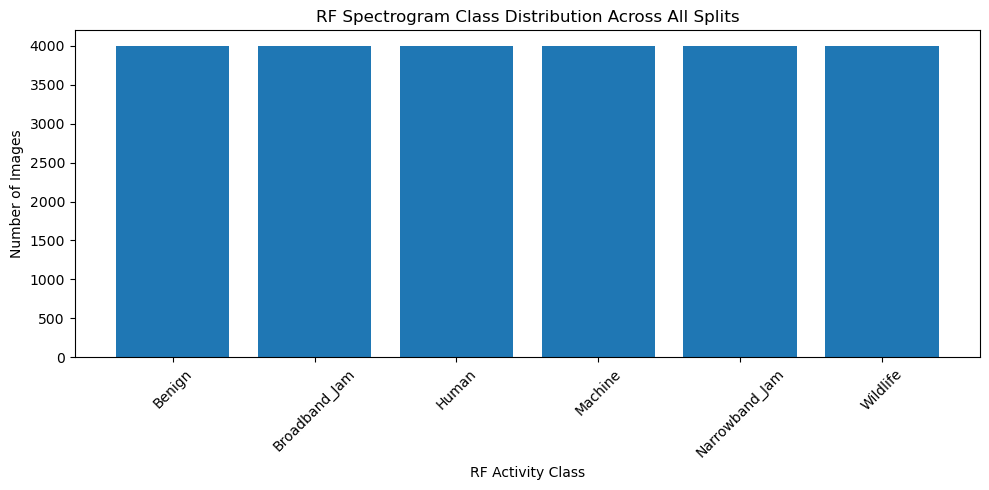

In [20]:
# Visualize Class Distribution

totals_by_class = [
    train_counts[c] + val_counts[c] + test_counts[c] + production_counts[c]
    for c in class_names
]

plt.figure(figsize=(10, 5))
plt.bar(class_names, totals_by_class)

plt.title("RF Spectrogram Class Distribution Across All Splits")
plt.xlabel("RF Activity Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.5 RF Spectrogram Visualization

Sample spectrograms from each RF activity class are displayed to provide a visual understanding of the input data.

These images represent time-frequency characteristics of RF activity that the classification model will learn to distinguish.


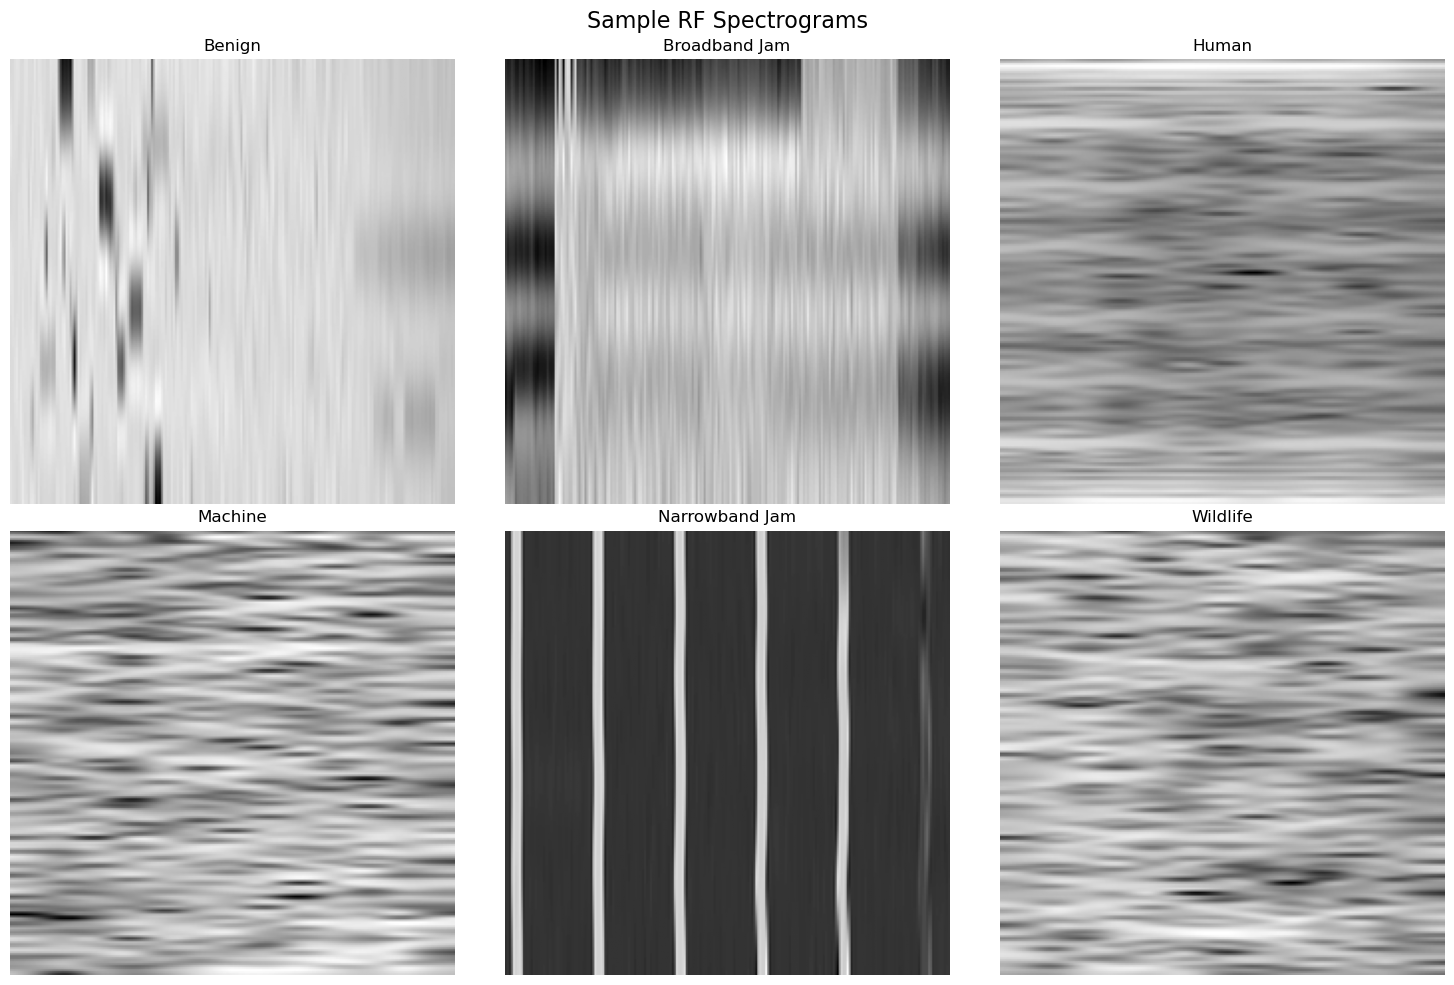

In [21]:
# Display One Spectrogram from Each Class

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):

    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file
        for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    ]

    sample_file = random.choice(image_files)
    image_path = os.path.join(class_dir, sample_file)

    with Image.open(image_path) as image:
        plt.subplot(2, 3, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(class_name.replace("_", " "))
        plt.axis("off")

plt.suptitle("Sample RF Spectrograms", fontsize=16)
plt.tight_layout()
plt.show()


### 7.6 Image Properties and Data Quality

The image dimensions and color modes are inspected to verify the consistency of the RF spectrogram data before model development.


In [22]:
# Inspect Spectrogram Image Properties

sample_class = class_names[0]

sample_files = [
    file for file in os.listdir(os.path.join(train_dir, sample_class))
    if file.lower().endswith(".png")
]

sample_path = os.path.join(
    train_dir,
    sample_class,
    sample_files[0]
)

with Image.open(sample_path) as sample_image:
    print("Class:", sample_class)
    print("Image size:", sample_image.size)
    print("Image mode:", sample_image.mode)
    print("Image format:", sample_image.format)


Class: Benign
Image size: (224, 224)
Image mode: L
Image format: PNG


### 7.7 Image Consistency Check

A sample of training images is reviewed across all six RF classes to confirm that image dimensions and formats are consistent across the dataset.


In [23]:
# Check Image Dimensions Across All Classes

image_sizes = Counter()
image_modes = Counter()

samples_per_class = 100
sampled = 0

for class_name in class_names:

    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    ]

    sample_files = image_files[:samples_per_class]

    for file in sample_files:

        image_path = os.path.join(class_dir, file)

        with Image.open(image_path) as img:
            image_sizes[img.size] += 1
            image_modes[img.mode] += 1

        sampled += 1

print("Sampled images:", sampled)

print("\nImage dimensions:")
for size, count in image_sizes.items():
    print(size, ":", count)

print("\nImage modes:")
for mode, count in image_modes.items():
    print(mode, ":", count)


Sampled images: 600

Image dimensions:
(224, 224) : 600

Image modes:
L : 600


### 7.8 Multiple Spectrogram Samples per Class

Displaying several examples from each RF activity class provides a clearer view of within-class variability and helps confirm that classes are visually distinguishable.


In [ ]:
# ============================================
# Multiple Samples per RF Class
# ============================================

SAMPLES_PER_CLASS = 4

fig, axes = plt.subplots(
    len(class_names),
    SAMPLES_PER_CLASS,
    figsize=(3 * SAMPLES_PER_CLASS, 2.6 * len(class_names))
)

rng = random.Random(SEED)

for row, class_name in enumerate(class_names):
    class_dir = Path(train_dir) / class_name
    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".png")
    ]
    sample_files = rng.sample(image_files, k=min(SAMPLES_PER_CLASS, len(image_files)))

    for col, sample_file in enumerate(sample_files):
        image_path = class_dir / sample_file
        with Image.open(image_path) as image:
            axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                class_name.replace("_", " "),
                rotation=0,
                ha="right",
                va="center",
                fontsize=10
            )

fig.suptitle("Multiple RF Spectrogram Samples per Class", fontsize=14)
plt.tight_layout()
plt.show()


### 7.9 Side-by-Side Class Comparison (Benign vs Jamming)

Benign activity is compared directly with broadband and narrowband jamming patterns. These classes are especially important for intrusion detection because jamming should produce distinct time-frequency signatures.


In [ ]:
# ============================================
# Benign vs Broadband Jam vs Narrowband Jam
# ============================================

compare_classes = ["Benign", "Broadband_Jam", "Narrowband_Jam"]
n_examples = 3

fig, axes = plt.subplots(
    len(compare_classes),
    n_examples,
    figsize=(3.2 * n_examples, 3 * len(compare_classes))
)

rng = random.Random(SEED + 1)

for row, class_name in enumerate(compare_classes):
    class_dir = Path(train_dir) / class_name
    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".png")
    ]
    sample_files = rng.sample(image_files, k=min(n_examples, len(image_files)))

    for col, sample_file in enumerate(sample_files):
        image_path = class_dir / sample_file
        with Image.open(image_path) as image:
            axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                class_name.replace("_", " "),
                rotation=0,
                ha="right",
                va="center",
                fontsize=11
            )
        if row == 0:
            axes[row, col].set_title(f"Example {col + 1}")

fig.suptitle("Benign vs Jamming Spectrogram Comparison", fontsize=14)
plt.tight_layout()
plt.show()


### 7.10 Pixel Intensity Statistics by Class

Pixel intensity summaries (mean, standard deviation, min, and max) are computed per class to characterize brightness/contrast differences and to support later preprocessing decisions such as normalization.


In [ ]:
# ============================================
# Pixel / Intensity Statistics by Class
# ============================================

samples_per_class = 150
intensity_rows = []

rng = random.Random(SEED + 2)

for class_name in class_names:
    class_dir = Path(train_dir) / class_name
    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".png")
    ]
    sample_files = rng.sample(image_files, k=min(samples_per_class, len(image_files)))

    pixel_values = []
    for sample_file in sample_files:
        with Image.open(class_dir / sample_file) as img:
            arr = np.asarray(img, dtype=np.float32)
            pixel_values.append(arr.ravel())

    pixels = np.concatenate(pixel_values)

    intensity_rows.append({
        "class": class_name,
        "n_images": len(sample_files),
        "mean": float(pixels.mean()),
        "std": float(pixels.std()),
        "min": float(pixels.min()),
        "max": float(pixels.max()),
        "p25": float(np.percentile(pixels, 25)),
        "p50": float(np.percentile(pixels, 50)),
        "p75": float(np.percentile(pixels, 75)),
    })

intensity_df = pd.DataFrame(intensity_rows)
print("Pixel intensity statistics by class (0-255 grayscale scale)\n")
display(intensity_df.round(2))

# Mean intensity bar chart
plt.figure(figsize=(10, 5))
plt.bar(intensity_df["class"], intensity_df["mean"], yerr=intensity_df["std"], capsize=4)
plt.title("Mean Pixel Intensity by RF Class (±1 std)")
plt.xlabel("RF Activity Class")
plt.ylabel("Mean Pixel Intensity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Intensity histogram overlay
plt.figure(figsize=(10, 5))
for class_name in class_names:
    class_dir = Path(train_dir) / class_name
    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(".png")
    ]
    sample_files = rng.sample(image_files, k=min(40, len(image_files)))
    vals = []
    for sample_file in sample_files:
        with Image.open(class_dir / sample_file) as img:
            vals.append(np.asarray(img, dtype=np.float32).ravel())
    vals = np.concatenate(vals)
    plt.hist(vals, bins=40, alpha=0.35, density=True, label=class_name.replace("_", " "))

plt.title("Pixel Intensity Distribution by Class")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 7.11 Filename / Source Provenance Analysis

Image filenames contain prefixes such as `radar_`, `dronerf_`, `jam_`, and `aug_`. Counting these prefixes helps identify mixed data sources and augmentation artifacts, which is useful for bias checks and later monitoring/drift analysis.


In [ ]:
# ============================================
# Filename / Source Provenance Analysis
# ============================================

import re

def extract_prefix(filename: str) -> str:
    stem = Path(filename).stem
    # Common patterns in this dataset: radar_, dronerf_, jam_*, aug_*
    if stem.startswith("aug_"):
        return "aug_"
    if stem.startswith("dronerf_"):
        return "dronerf_"
    if stem.startswith("radar_"):
        return "radar_"
    if stem.startswith("jam_"):
        return "jam_"
    # fallback: text before first digit sequence or first underscore group
    match = re.match(r"^([A-Za-z]+_?)", stem)
    return match.group(1) if match else "other"


provenance_rows = []

for split_name, split_dir in [
    ("train", train_dir),
    ("validation", val_dir),
    ("test", test_dir),
    ("production", production_dir),
]:
    for class_name in class_names:
        class_dir = Path(split_dir) / class_name
        for file in os.listdir(class_dir):
            if not file.lower().endswith(".png"):
                continue
            provenance_rows.append({
                "assignment_split": split_name,
                "class_label": class_name,
                "prefix": extract_prefix(file),
                "filename": file,
            })

provenance_df = pd.DataFrame(provenance_rows)

print("Overall filename prefix counts:\n")
prefix_counts = (
    provenance_df["prefix"]
    .value_counts()
    .rename_axis("prefix")
    .reset_index(name="count")
)
display(prefix_counts)

print("\nPrefix counts by class:\n")
prefix_by_class = (
    provenance_df
    .groupby(["class_label", "prefix"])
    .size()
    .unstack(fill_value=0)
    .reindex(class_names)
)
display(prefix_by_class)

print("\nPrefix counts by assignment split:\n")
prefix_by_split = (
    provenance_df
    .groupby(["assignment_split", "prefix"])
    .size()
    .unstack(fill_value=0)
    .reindex(["train", "validation", "test", "production"])
)
display(prefix_by_split)

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(prefix_counts["prefix"], prefix_counts["count"])
plt.title("RF Image Filename Prefix Distribution")
plt.xlabel("Filename Prefix / Source Hint")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Stacked bar by class
ax = prefix_by_class.plot(kind="bar", stacked=True, figsize=(11, 5))
ax.set_title("Filename Prefix Mix by RF Class")
ax.set_xlabel("RF Activity Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Image Preprocessing and TensorFlow Data Pipeline

The training, validation, and test directories are converted into TensorFlow datasets for model development and evaluation.

The production split is intentionally kept separate from model training. It represents holdout data that can later be used for production-style inference, monitoring, or drift analysis.

The original spectrogram files remain unchanged at their original resolution. For CPU-efficient baseline training in the AWS Academy SageMaker environment, TensorFlow resizes the model inputs to 128 × 128 pixels, loads them as RGB tensors, and processes them in batches of 32.


### 8.1 Create TensorFlow Image Datasets

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

print("\nClasses:")
print(train_ds.class_names)


### 8.2 Input Pipeline Optimization

TensorFlow prefetching is used to improve data-loading efficiency by preparing future batches while the model processes the current batch.

This helps reduce input bottlenecks during training.


In [ ]:
# Optimize Input Pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("TensorFlow datasets ready.")


### 8.3 Data Preparation Summary

The RF spectrogram dataset has been prepared for model development using the curated S3 data lake split. The data was synced from S3 into the SageMaker Studio environment so TensorFlow could load the images from local folders.

The training, validation, and test splits are used for model development and evaluation. The production split is kept separate as a holdout dataset for later production-style inference or monitoring.

All six RF activity classes are identified, class balance is evaluated, and image dimensions and formats are checked. The TensorFlow input pipeline resizes model inputs to 128 × 128 pixels, loads the images as RGB tensors, applies categorical labels for multi-class classification, and uses prefetching to improve data-loading efficiency.


## 9. Baseline CNN Model

A baseline convolutional neural network (CNN) is developed to classify the six RF spectrogram categories.

The baseline model provides an initial performance benchmark that can later be compared against more advanced architectures or transfer-learning approaches.


### 9.1 Build Baseline CNN Model

In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()


### 9.2 Compile Baseline CNN

The baseline CNN is compiled using the Adam optimizer and categorical cross-entropy loss, which is appropriate for this six-class classification problem. Accuracy is tracked during training as an initial performance metric.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline CNN compiled successfully.")


### 9.3 Baseline CNN Training

The baseline CNN is trained using the prepared training dataset and evaluated against the validation dataset after each epoch.

Early stopping is used to reduce unnecessary training if validation loss stops improving, while the best-performing model weights are restored automatically.


In [25]:
# ============================================
# Baseline CNN Training
# ============================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 254s 480ms/step - accuracy: 0.5752 - loss: 0.9370 - val_accuracy: 0.6986 - val_loss: 0.6491
Epoch 2/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 243s 462ms/step - accuracy: 0.6906 - loss: 0.6527 - val_accuracy: 0.7261 - val_loss: 0.5751
Epoch 3/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 270s 478ms/step - accuracy: 0.7100 - loss: 0.6011 - val_accuracy: 0.7025 - val_loss: 0.6494
Epoch 4/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 257s 468ms/step - accuracy: 0.7198 - loss: 0.5669 - val_accuracy: 0.7294 - val_loss: 0.5441
Epoch 5/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 254s 453ms/step - accuracy: 0.7282 - loss: 0.5600 - val_accuracy: 0.7075 - val_loss: 0.5441
Epoch 6/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 243s 464ms/step - accuracy: 0.7387 - loss: 0.5366 - val_accuracy: 0.7364 - val_loss: 0.5475
Epoch 7/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 245s 468ms/step - accuracy: 0.7455 - loss: 0.5207 - val_accuracy: 0.7469 - val_loss: 0.5436
Epoch 8/15
525/525 ━━━━━━━━━━━━━━━━━━━━ 264s 472ms/step - accuracy: 0.7562 -

## 16. Test Set Evaluation

The trained baseline CNN is evaluated on the held-out test dataset to measure how well it generalizes to previously unseen RF spectrograms.

The test loss and test accuracy provide an overall performance benchmark that will later be compared against the improved CNN model.

In [26]:
# ============================================
# Test Set Evaluation
# ============================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nBaseline CNN Test Results")
print("-------------------------")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8122 - loss: 0.4076

Baseline CNN Test Results
-------------------------
Test Loss:     0.4076
Test Accuracy: 0.8122


## 17. Classification Performance and Confusion Matrix

Overall test accuracy provides a useful summary of model performance, but it does not show how well the CNN performs on each individual RF activity class.

This section evaluates the baseline CNN using class-level precision, recall, and F1-score. A confusion matrix is also generated to identify which RF activity classes are most frequently confused by the model. These results will serve as a detailed reference when evaluating the improved CNN.

  1/113 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step

2026-09-26 00:04:28.625175: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step
Baseline CNN Classification Report
----------------------------------
                precision    recall  f1-score   support

        Benign     0.6865    0.8650    0.7655       600
 Broadband_Jam     0.9164    0.9867    0.9502       600
         Human     0.8754    0.8783    0.8769       600
       Machine     0.6416    0.4417    0.5232       600
Narrowband_Jam     0.9900    0.9933    0.9917       600
      Wildlife     0.7315    0.7083    0.7197       600

      accuracy                         0.8122      3600
     macro avg     0.8069    0.8122    0.8045      3600
  weighted avg     0.8069    0.8122    0.8045      3600



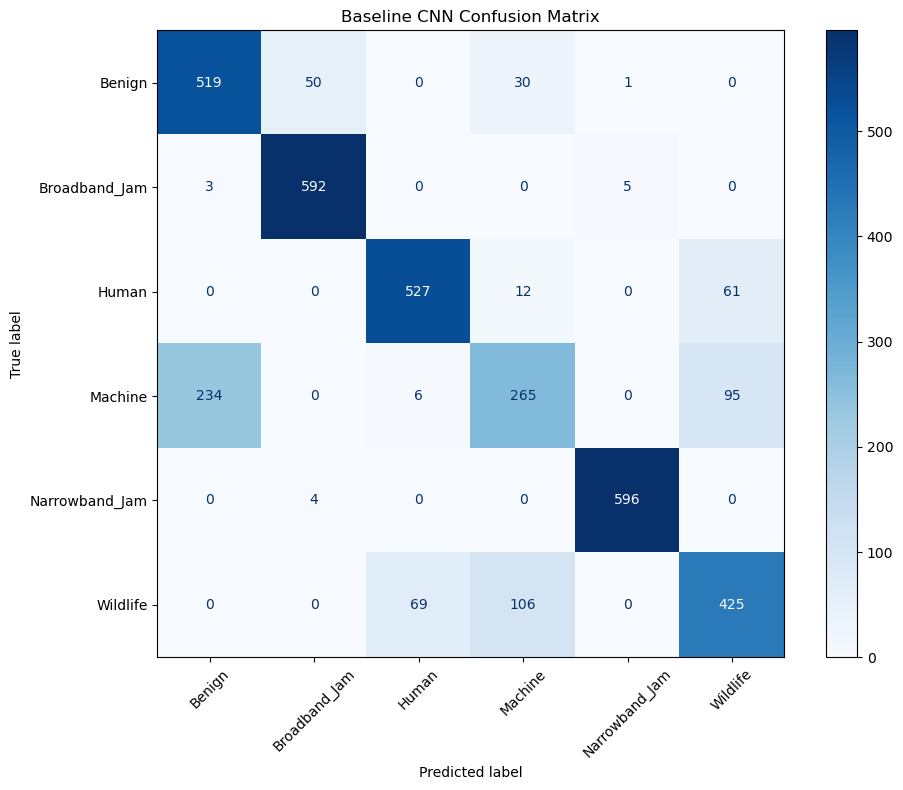

In [27]:
# ============================================
# Classification Performance
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Collect true labels from the test dataset
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_ds
])

# Generate class probabilities
y_prob = model.predict(
    test_ds,
    verbose=1
)

# Convert probabilities to predicted class labels
y_pred = np.argmax(
    y_prob,
    axis=1
)

# Classification report
print("Baseline CNN Classification Report")
print("----------------------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline CNN Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Baseline Model Results

The baseline CNN achieved 81.22% accuracy on the held-out test dataset with a macro F1-score of approximately 0.8045.

Performance was strongest for the Broadband_Jam and Narrowband_Jam classes. The primary weakness was the Machine class, which achieved only 44.17% recall and an F1-score of approximately 0.5232. The confusion matrix shows that Machine samples were most frequently misclassified as Benign or Wildlife.

These baseline results establish the reference performance for the next model iteration. The improved CNN will focus on increasing overall classification performance while reducing confusion among the Benign, Machine, and Wildlife classes.

In [28]:
# ============================================
# Store Baseline CNN Results
# ============================================

from sklearn.metrics import precision_recall_fscore_support

baseline_precision, baseline_recall, baseline_macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

baseline_results = {
    "model": "Baseline CNN v1",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(baseline_precision),
    "macro_recall": float(baseline_recall),
    "macro_f1": float(baseline_macro_f1)
}

print("Baseline CNN v1 Results")
print("-----------------------")

for metric, value in baseline_results.items():
    if metric == "model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Baseline CNN v1 Results
-----------------------
model: Baseline CNN v1
test_loss: 0.4076
test_accuracy: 0.8122
macro_precision: 0.8069
macro_recall: 0.8122
macro_f1: 0.8045


## 19. Preserve Baseline CNN for Comparison

The trained baseline CNN is retained as Model v1 before developing the improved architecture.

Keeping the baseline and improved models separate allows both versions to be evaluated using the same test dataset and performance metrics. This provides a consistent comparison of accuracy, precision, recall, F1-score, and class-level performance.

In [29]:
# ============================================
# Preserve Baseline CNN v1
# ============================================

baseline_model = model

print("Baseline CNN v1 preserved for comparison.")
print(f"Baseline Test Accuracy: {baseline_results['test_accuracy']:.4f}")
print(f"Baseline Macro F1:      {baseline_results['macro_f1']:.4f}")

Baseline CNN v1 preserved for comparison.
Baseline Test Accuracy: 0.8122
Baseline Macro F1:      0.8045


## 20. Improved CNN v2 Architecture

The second CNN iteration builds on the baseline model by increasing feature-extraction capacity while maintaining a relatively lightweight architecture.

The improved model adds batch normalization after each convolutional layer to stabilize training and introduces a fourth convolutional block to capture more complex patterns in the RF spectrograms. Dropout is also increased to provide additional regularization.

The goal of this iteration is to improve overall classification performance, with particular attention to the Machine class, which showed the weakest recall and F1-score in the baseline CNN.

In [30]:
# ============================================
# Improved CNN v2 Architecture
# ============================================

improved_model = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    ),

    tf.keras.layers.Rescaling(1./255),

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Convolution Block 4
    tf.keras.layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        use_bias=False
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    # Classification Head
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,526 (1.62 MB)

 Trainable params: 422,566 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 21. Improved CNN v2 Compilation

The improved CNN is compiled using the Adam optimizer and categorical cross-entropy loss, consistent with the six-class classification objective.

A slightly lower learning rate than the baseline model is used to support more stable optimization of the deeper network. Accuracy is retained as the primary training metric, while precision, recall, and F1-score will be calculated during final evaluation.

In [31]:
# ============================================
# Improved CNN v2 Compilation
# ============================================

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN v2 compiled successfully.")
print("Optimizer: Adam")
print("Learning Rate: 0.0005")
print("Loss: categorical_crossentropy")
print("Metric: accuracy")

Improved CNN v2 compiled successfully.
Optimizer: Adam
Learning Rate: 0.0005
Loss: categorical_crossentropy
Metric: accuracy


## 22. Improved CNN v2 Training

The improved CNN is trained using the same training and validation datasets as the baseline model to maintain a fair comparison.

Early stopping is used to restore the model weights associated with the lowest validation loss if performance stops improving. A learning-rate reduction callback is also included to decrease the learning rate when validation loss plateaus, allowing the optimizer to make smaller adjustments as training progresses.

The improved model is trained for a maximum of 20 epochs, although training may stop earlier if validation performance no longer improves.

In [32]:
# ============================================
# Improved CNN v2 Training
# ============================================

improved_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_v2 = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        improved_early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 463s 878ms/step - accuracy: 0.6783 - loss: 0.6863 - val_accuracy: 0.6417 - val_loss: 0.7760 - learning_rate: 5.0000e-04
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 464s 884ms/step - accuracy: 0.7351 - loss: 0.5496 - val_accuracy: 0.6961 - val_loss: 0.5709 - learning_rate: 5.0000e-04
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 468s 892ms/step - accuracy: 0.7579 - loss: 0.4982 - val_accuracy: 0.7253 - val_loss: 0.5383 - learning_rate: 5.0000e-04
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 465s 887ms/step - accuracy: 0.7771 - loss: 0.4495 - val_accuracy: 0.5914 - val_loss: 0.9588 - learning_rate: 5.0000e-04
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.7906 - loss: 0.4212
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
525/525 ━━━━━━━━━━━━━━━━━━━━ 467s 889ms/step - accuracy: 0.7906 - loss: 0.4212 - val_accuracy: 0.6997 - val_loss: 0.9361 - learning_rate: 5.0000e-04
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 501s 88

## 23. Improved CNN v2 Test Evaluation

The improved CNN is evaluated on the same held-out test dataset used for the baseline model.

Using the same test data ensures a consistent comparison between Model v1 and Model v2. Test loss and accuracy are recorded before performing a more detailed class-level evaluation.

In [33]:
# ============================================
# Improved CNN v2 Test Evaluation
# ============================================

improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    test_ds,
    verbose=1
)

print("\nImproved CNN v2 Test Results")
print("----------------------------")
print(f"Test Loss:     {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")

print("\nBaseline CNN v1 Reference")
print("-------------------------")
print(f"Test Loss:     {baseline_results['test_loss']:.4f}")
print(f"Test Accuracy: {baseline_results['test_accuracy']:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.8278 - loss: 0.3454

Improved CNN v2 Test Results
----------------------------
Test Loss:     0.3454
Test Accuracy: 0.8278

Baseline CNN v1 Reference
-------------------------
Test Loss:     0.4076
Test Accuracy: 0.8122


## 24. Improved CNN v2 Classification Performance

The improved CNN is evaluated using class-level precision, recall, and F1-score to determine whether the architecture changes improved performance beyond overall test accuracy.

Particular attention is given to the Machine class, which was the weakest-performing class in the baseline CNN. A confusion matrix is also generated to identify whether misclassification among the Benign, Machine, and Wildlife classes has been reduced.

113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step
Improved CNN v2 Classification Report
-------------------------------------
                precision    recall  f1-score   support

        Benign     0.7053    0.8933    0.7882       600
 Broadband_Jam     0.9579    0.9867    0.9721       600
         Human     0.9375    0.8750    0.9052       600
       Machine     0.7667    0.2683    0.3975       600
Narrowband_Jam     0.9803    0.9933    0.9868       600
      Wildlife     0.6754    0.9500    0.7895       600

      accuracy                         0.8278      3600
     macro avg     0.8372    0.8278    0.8065      3600
  weighted avg     0.8372    0.8278    0.8065      3600



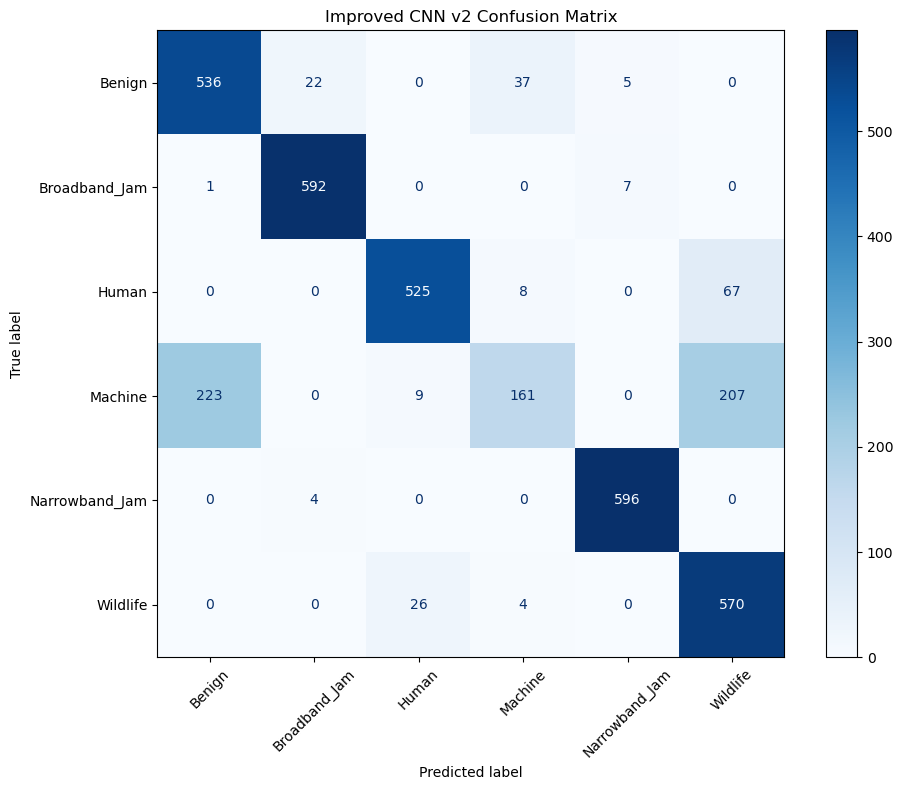

In [34]:
# ============================================
# Improved CNN v2 Classification Performance
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

# Generate improved model probabilities
improved_y_prob = improved_model.predict(
    test_ds,
    verbose=1
)

# Convert probabilities to class predictions
improved_y_pred = np.argmax(
    improved_y_prob,
    axis=1
)

# Classification report
print("Improved CNN v2 Classification Report")
print("-------------------------------------")

print(
    classification_report(
        y_true,
        improved_y_pred,
        target_names=class_names,
        digits=4
    )
)

# Calculate macro metrics
(
    improved_macro_precision,
    improved_macro_recall,
    improved_macro_f1,
    _
) = precision_recall_fscore_support(
    y_true,
    improved_y_pred,
    average="macro",
    zero_division=0
)

# Confusion matrix
improved_cm = confusion_matrix(
    y_true,
    improved_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Improved CNN v2 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 25. Baseline vs Improved CNN Comparison

The improved CNN achieved higher overall test accuracy and lower test loss than the baseline CNN. Test accuracy increased from 81.22% to 82.78%, while test loss decreased from 0.4076 to 0.3454.

Macro F1-score also increased slightly from 0.8045 to 0.8065. However, the class-level results show an important tradeoff. Performance for the Wildlife class improved substantially, while recall and F1-score for the Machine class decreased.

The improved model therefore demonstrates stronger overall classification performance but still requires additional refinement to better distinguish Machine activity from Benign and Wildlife RF patterns.

In [35]:
# ============================================
# Baseline vs Improved CNN Comparison
# ============================================

comparison_results = {
    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Baseline CNN v1": [
        baseline_results["test_accuracy"],
        baseline_results["test_loss"],
        baseline_results["macro_precision"],
        baseline_results["macro_recall"],
        baseline_results["macro_f1"]
    ],
    "Improved CNN v2": [
        improved_test_accuracy,
        improved_test_loss,
        improved_macro_precision,
        improved_macro_recall,
        improved_macro_f1
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison_results)

print("Baseline CNN v1 vs Improved CNN v2")
print("-----------------------------------")
print(comparison_df.to_string(index=False))

Baseline CNN v1 vs Improved CNN v2
-----------------------------------
         Metric  Baseline CNN v1  Improved CNN v2
  Test Accuracy         0.812222         0.827778
      Test Loss         0.407642         0.345406
Macro Precision         0.806918         0.837163
   Macro Recall         0.812222         0.827778
       Macro F1         0.804535         0.806542


## 26. Save Improved CNN v2

The improved CNN is saved as a separate model artifact so that it can be evaluated independently from the baseline CNN.

Model v2 achieved higher overall test accuracy and lower test loss than Model v1. The saved artifact preserves the trained model for additional evaluation, comparison, and deployment work by the project team.

In [36]:
# ============================================
# Save Improved CNN v2
# ============================================

improved_model_filename = "improved_cnn_rf_intrusion_v2.keras"

improved_model.save(
    improved_model_filename
)

print("Improved CNN v2 saved successfully.")
print(f"Model file: {improved_model_filename}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Test Loss:     {improved_test_loss:.4f}")
print(f"Macro F1:      {improved_macro_f1:.4f}")

Improved CNN v2 saved successfully.
Model file: improved_cnn_rf_intrusion_v2.keras
Test Accuracy: 0.8278
Test Loss:     0.3454
Macro F1:      0.8065


## 27. Improved CNN v2 Metadata

Metadata is created for the improved CNN to document the model version, architecture, training configuration, class labels, and evaluation results.

Saving this information alongside the trained model improves reproducibility and gives the project team a clear record of the exact model being evaluated and prepared for deployment.

In [40]:
# ============================================
# Improved CNN v2 Metadata
# ============================================

import json
from datetime import datetime, timezone

improved_model_metadata = {
    "model_name": "Improved CNN RF Intrusion Detection",
    "model_version": "v2",
    "model_type": "Convolutional Neural Network",

    "input_shape": [
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ],

    "num_classes": num_classes,
    "class_names": list(class_names),

    "architecture": {
        "convolution_blocks": 4,
        "filters": [32, 64, 128, 256],
        "batch_normalization": True,
        "dense_units": 128,
        "dropout_rate": 0.40
    },

    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": 0.0005,
        "loss": "categorical_crossentropy",
        "max_epochs": 20,
        "early_stopping": True,
        "reduce_lr_on_plateau": True
    },

    "evaluation": {
        "test_loss": float(improved_test_loss),
        "test_accuracy": float(improved_test_accuracy),
        "macro_precision": float(improved_macro_precision),
        "macro_recall": float(improved_macro_recall),
        "macro_f1": float(improved_macro_f1)
    },

    "created_utc": datetime.now(
        timezone.utc
    ).isoformat()
}

improved_metadata_filename = (
    "improved_cnn_rf_intrusion_v2_metadata.json"
)

with open(
    improved_metadata_filename,
    "w"
) as f:
    json.dump(
        improved_model_metadata,
        f,
        indent=4
    )

print("Improved CNN v2 metadata saved successfully.")
print(f"Metadata file: {improved_metadata_filename}")

print("\nModel Metadata")
print("--------------")
print(
    json.dumps(
        improved_model_metadata,
        indent=4
    )
)

Improved CNN v2 metadata saved successfully.
Metadata file: improved_cnn_rf_intrusion_v2_metadata.json

Model Metadata
--------------
{
    "model_name": "Improved CNN RF Intrusion Detection",
    "model_version": "v2",
    "model_type": "Convolutional Neural Network",
    "input_shape": [
        128,
        128,
        3
    ],
    "num_classes": 6,
    "class_names": [
        "Benign",
        "Broadband_Jam",
        "Human",
        "Machine",
        "Narrowband_Jam",
        "Wildlife"
    ],
    "architecture": {
        "convolution_blocks": 4,
        "filters": [
            32,
            64,
            128,
            256
        ],
        "batch_normalization": true,
        "dense_units": 128,
        "dropout_rate": 0.4
    },
    "training": {
        "optimizer": "Adam",
        "initial_learning_rate": 0.0005,
        "loss": "categorical_crossentropy",
        "max_epochs": 20,
        "early_stopping": true,
        "reduce_lr_on_plateau": true
    },
    "e

In [42]:
# ============================================
# S3 Client Setup
# ============================================

import boto3

region = "us-east-1"

bucket = (
    "aai540-group6-rf-intrusion-2026-"
    "003274228913-us-east-1-an"
)

s3 = boto3.client(
    "s3",
    region_name=region
)

print("S3 client initialized.")
print(f"Bucket: {bucket}")
print(f"Region: {region}")

S3 client initialized.
Bucket: aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an
Region: us-east-1


## 28. Upload Improved CNN v2 to S3

The improved CNN model and its metadata are uploaded to Amazon S3 using a versioned model path.

Storing both artifacts in S3 ensures the trained model is preserved independently of the current SageMaker session and provides a shared location for team evaluation, deployment, and future model management activities.

In [43]:
# ============================================
# Upload Improved CNN v2 to S3
# ============================================

improved_model_version = "v2"

improved_model_key = (
    f"models/improved/{improved_model_version}/"
    f"{improved_model_filename}"
)

improved_metadata_key = (
    f"models/improved/{improved_model_version}/"
    f"{improved_metadata_filename}"
)

# Upload improved model
s3.upload_file(
    improved_model_filename,
    bucket,
    improved_model_key
)

# Upload metadata
s3.upload_file(
    improved_metadata_filename,
    bucket,
    improved_metadata_key
)

improved_model_s3_uri = (
    f"s3://{bucket}/{improved_model_key}"
)

improved_metadata_s3_uri = (
    f"s3://{bucket}/{improved_metadata_key}"
)

print("Improved CNN v2 uploaded successfully.")
print()
print("Model:")
print(improved_model_s3_uri)
print()
print("Metadata:")
print(improved_metadata_s3_uri)

Improved CNN v2 uploaded successfully.

Model:
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2.keras

Metadata:
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2_metadata.json


## 29. Verify Improved CNN v2 Artifacts in S3

The uploaded improved CNN artifacts are verified in Amazon S3 to confirm that both the trained model and metadata file were stored successfully.

This verification step helps ensure the model is available for team evaluation and later deployment activities.

In [44]:
# ============================================
# Verify Improved CNN v2 Artifacts in S3
# ============================================

model_head = s3.head_object(
    Bucket=bucket,
    Key=improved_model_key
)

metadata_head = s3.head_object(
    Bucket=bucket,
    Key=improved_metadata_key
)

model_size_mb = model_head["ContentLength"] / (1024 * 1024)
metadata_size_kb = metadata_head["ContentLength"] / 1024

print("Improved CNN v2 S3 Verification")
print("--------------------------------")
print(f"Model found:    YES")
print(f"Model size:     {model_size_mb:.2f} MB")
print()
print(f"Metadata found: YES")
print(f"Metadata size:  {metadata_size_kb:.2f} KB")

Improved CNN v2 S3 Verification
--------------------------------
Model found:    YES
Model size:     4.92 MB

Metadata found: YES
Metadata size:  1.13 KB


## 30. Improved CNN v2 Team Handoff

The improved CNN v2 model is ready for independent team evaluation.

Model v2 improved overall test accuracy from 81.22% to 82.78% and reduced test loss from 0.4076 to 0.3454 compared with the baseline CNN. Macro F1-score increased slightly from 0.8045 to 0.8065.

Class-level evaluation showed that overall performance improved, although the Machine class remains an area for future refinement. The trained model and associated metadata have been stored in the shared Amazon S3 bucket so they can be accessed for additional evaluation and deployment activities.

In [45]:
# ============================================
# Improved CNN v2 Team Handoff
# ============================================

print("Improved CNN v2 - Team Handoff")
print("--------------------------------")
print(f"Model Version:       v2")
print(f"Test Accuracy:       {improved_test_accuracy:.4f}")
print(f"Test Loss:           {improved_test_loss:.4f}")
print(f"Macro F1:            {improved_macro_f1:.4f}")

print("\nBaseline Reference")
print("------------------")
print(f"Baseline Accuracy:   {baseline_results['test_accuracy']:.4f}")
print(f"Baseline Macro F1:   {baseline_results['macro_f1']:.4f}")

print("\nS3 Model Artifact")
print("-----------------")
print(improved_model_s3_uri)

print("\nS3 Metadata Artifact")
print("--------------------")
print(improved_metadata_s3_uri)

Improved CNN v2 - Team Handoff
--------------------------------
Model Version:       v2
Test Accuracy:       0.8278
Test Loss:           0.3454
Macro F1:            0.8065

Baseline Reference
------------------
Baseline Accuracy:   0.8122
Baseline Macro F1:   0.8045

S3 Model Artifact
-----------------
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2.keras

S3 Metadata Artifact
--------------------
s3://aai540-group6-rf-intrusion-2026-003274228913-us-east-1-an/models/improved/v2/improved_cnn_rf_intrusion_v2_metadata.json


## 31. Independent Evaluation: Baseline CNN vs Improved CNN v2

This section re-evaluates Improved CNN v2 against the preserved baseline using the same held-out test set. Overall metrics are compared first, then class-level precision, recall, and F1-score are used to identify which RF activity categories improved or got worse.


In [ ]:
# ============================================
# Per-Class Evaluation: Baseline CNN vs Improved CNN v2
# ============================================

from sklearn.metrics import precision_recall_fscore_support

baseline_class_p, baseline_class_r, baseline_class_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        zero_division=0
    )
)

improved_class_p, improved_class_r, improved_class_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        improved_y_pred,
        average=None,
        zero_division=0
    )
)

class_comparison_df = pd.DataFrame({
    "class": class_names,
    "baseline_precision": baseline_class_p,
    "v2_precision": improved_class_p,
    "precision_delta": improved_class_p - baseline_class_p,
    "baseline_recall": baseline_class_r,
    "v2_recall": improved_class_r,
    "recall_delta": improved_class_r - baseline_class_r,
    "baseline_f1": baseline_class_f1,
    "v2_f1": improved_class_f1,
    "f1_delta": improved_class_f1 - baseline_class_f1,
})

print("Overall Test Comparison")
print("-----------------------")
print(
    f"{'Metric':<18}"
    f"{'Baseline v1':>14}"
    f"{'Improved v2':>14}"
    f"{'Delta':>10}"
)
print("-" * 56)

for metric, base_val, v2_val in [
    ("Test Accuracy", baseline_results["test_accuracy"], improved_test_accuracy),
    ("Test Loss", baseline_results["test_loss"], improved_test_loss),
    ("Macro Precision", baseline_results["macro_precision"], improved_macro_precision),
    ("Macro Recall", baseline_results["macro_recall"], improved_macro_recall),
    ("Macro F1", baseline_results["macro_f1"], improved_macro_f1),
]:
    print(
        f"{metric:<18}"
        f"{base_val:>14.4f}"
        f"{v2_val:>14.4f}"
        f"{v2_val - base_val:>+10.4f}"
    )

print("\nPer-Class Precision / Recall / F1")
print("---------------------------------")
display(class_comparison_df.round(4))

x = np.arange(len(class_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x - width / 2, baseline_class_f1, width, label="Baseline CNN v1")
axes[0].bar(x + width / 2, improved_class_f1, width, label="Improved CNN v2")
axes[0].set_xticks(x)
axes[0].set_xticklabels([name.replace("_", " ") for name in class_names], rotation=45)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("F1-score")
axes[0].set_title("Per-Class F1: Baseline vs Improved CNN v2")
axes[0].legend()

axes[1].bar(x - width / 2, baseline_class_r, width, label="Baseline CNN v1")
axes[1].bar(x + width / 2, improved_class_r, width, label="Improved CNN v2")
axes[1].set_xticks(x)
axes[1].set_xticklabels([name.replace("_", " ") for name in class_names], rotation=45)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Recall")
axes[1].set_title("Per-Class Recall: Baseline vs Improved CNN v2")
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluation Findings

**Overall:** Improved CNN v2 is stronger as a global classifier. Test accuracy rose from **81.22% to 82.78%** (+1.56 points) and test loss fell from **0.4076 to 0.3454**. Macro precision improved more than macro F1 (0.8069 → 0.8372 vs 0.8045 → 0.8065), which means v2 is more confident on some classes but the gain is not uniform.

**What v2 improved**
- **Wildlife:** recall rose sharply (0.708 → 0.950), so fewer wildlife spectrograms are missed.
- **Benign:** both recall and F1 improved.
- **Broadband Jam / Human:** small F1 gains; jamming classes remain easy for both models.
- **Narrowband Jam:** already near-perfect in both models.

**What v2 made worse**
- **Machine** is the failure mode. Recall dropped from **0.4417 to 0.2683** and F1 from **0.5232 to 0.3975**. v2 trades Machine detections for Wildlife/Benign predictions.

**Conclusion:** Use v2 if the priority is overall accuracy and jamming/wildlife detection. Do **not** treat v2 as a finished model for intrusion-style Machine vs Benign separation. The next iteration should target Machine recall (class weights, focal loss, or more Machine-focused augmentation) rather than adding more generic capacity.
